In [35]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import imageio
import random
import math
import time
import heapq

In [36]:
plt.ion()
bbox = [-65.0897, -42.7959, -64.9932, -42.7494]
polygon = ox.utils_geo.bbox_to_poly(bbox)
graph = ox.graph_from_polygon(polygon, network_type="drive")

In [37]:
# from https://github.com/santifiorino/maps-pathfinding/
for edge in graph.edges:
    # Cleaning the "maxspeed" attribute, some values are lists, some are strings, some are None
    maxspeed = 40
    if "maxspeed" in graph.edges[edge]:
        maxspeed = graph.edges[edge]["maxspeed"]
        if type(maxspeed) == list:
            speeds = [ int(speed) for speed in maxspeed ]
            maxspeed = min(speeds)
        elif type(maxspeed) == str:
            maxspeed = int(maxspeed)
    graph.edges[edge]["maxspeed"] = maxspeed
    # Adding the "weight" attribute (time = distance / speed)
    graph.edges[edge]["weight"] = graph.edges[edge]["length"] / maxspeed

In [38]:
# from https://github.com/santifiorino/maps-pathfinding/
def style_unvisited_edge(edge):        
    graph.edges[edge]["color"] = "#d36206"
    graph.edges[edge]["alpha"] = 0.2
    graph.edges[edge]["linewidth"] = 0.5

def style_visited_edge(edge):
    graph.edges[edge]["color"] = "#d36206"
    graph.edges[edge]["alpha"] = 1
    graph.edges[edge]["linewidth"] = 1

def style_active_edge(edge):
    graph.edges[edge]["color"] = '#e8a900'
    graph.edges[edge]["alpha"] = 1
    graph.edges[edge]["linewidth"] = 1

def style_path_edge(edge):
    graph.edges[edge]["color"] = "white"
    graph.edges[edge]["alpha"] = 1
    graph.edges[edge]["linewidth"] = 1

In [39]:
def plot_graph():
    ox.plot_graph(
        graph,
        node_size =  [ graph.nodes[node]["size"] for node in graph.nodes ],
        edge_color = [ graph.edges[edge]["color"] for edge in graph.edges ],
        edge_alpha = [ graph.edges[edge]["alpha"] for edge in graph.edges ],
        edge_linewidth = [ graph.edges[edge]["linewidth"] for edge in graph.edges ],
        node_color = "white",
        bgcolor = "#18080e"
    )

In [40]:
# from https://github.com/santifiorino/maps-pathfinding/
def plot_heatmap(algorithm):
    edge_colors = ox.plot.get_edge_colors_by_attr(graph, f"{algorithm}_uses", cmap="hot")
    fig, _ = ox.plot_graph(
        graph,
        node_size = 0,
        edge_color = edge_colors,
        bgcolor = "#18080e"
    )

In [41]:
# from https://github.com/santifiorino/maps-pathfinding/
def reconstruct_map(orig, dest, plot=False, algorithm=None):
    for edge in graph.edges:
        style_unvisited_edge(edge)
    dist = 0
    speeds = []
    curr = dest
    while curr != orig:
        prev = graph.nodes[curr]["previous"]
        dist += graph.edges[(prev, curr, 0)]["length"]
        speeds.append(graph.edges[(prev, curr, 0)]["maxspeed"])
        style_path_edge((prev, curr, 0))
        if algorithm:
            graph.edges[(prev, curr, 0)][f"{algorithm}_uses"] = graph.edges[(prev, curr, 0)].get(f"{algorithm}_uses", 0) + 1
        curr = prev
    dist /= 1000
    if plot:
        print(f"Distance: {dist}")
        print(f"Avg. speed: {sum(speeds)/len(speeds)}")
        print(f"Total time: {dist/(sum(speeds)/len(speeds)) * 60}")
        plot_graph()

In [42]:
# from https://github.com/santifiorino/maps-pathfinding/
def reconstruct_path(orig, dest, plot=False, algorithm=None):
    for edge in graph.edges:
        style_unvisited_edge(edge)
    dist = 0
    speeds = []
    curr = dest
    while curr != orig:
        prev = graph.nodes[curr]["previous"]
        dist += graph.edges[(prev, curr, 0)]["length"]
        speeds.append(graph.edges[(prev, curr, 0)]["maxspeed"])
        style_path_edge((prev, curr, 0))
        if algorithm:
            graph.edges[(prev, curr, 0)][f"{algorithm}_uses"] = graph.edges[(prev, curr, 0)].get(f"{algorithm}_uses", 0) + 1
        curr = prev
    dist /= 1000
    if plot:
        print(f"Distance: {dist}")
        print(f"Avg. speed: {sum(speeds)/len(speeds)}")
        print(f"Total time: {dist/(sum(speeds)/len(speeds)) * 60}")
        plot_graph()

In [43]:
def get_coords(node):
    data = graph.nodes[node]
    return data["x"], data["y"]

In [44]:
def haversine_form(lat1, lon1, lat2, lon2):
    R = 6371000
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = math.sin(dlat / 2)**2 + \
        math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

In [45]:
def euclidean_distance(orig, dest):
    x1, y1 = get_coords(orig)
    x2, y2 = get_coords(dest)
    return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

In [46]:
def manhattan_distance(orig, dest):
    x1, y1 = get_coords(orig)
    x2, y2 = get_coords(dest)
    return abs(x2 - x1) + abs(y2 - y1)

In [47]:
def haversine_distance(orig, dest):
    x1, y1 = get_coords(orig)
    x2, y2 = get_coords(dest)

#    orig_coords = (math.radians(x), math.radians(coord1[1]))

    lat1, lon1 = math.radians(x1), math.radians(y1)
    lat2, lon2 = math.radians(x2), math.radians(y2)
    
    return haversine_form(lat1, lon1, lat2, lon2)

In [48]:
def a_star(orig, dest, plot=False):
    for node in graph.nodes:
        graph.nodes[node]["previous"] = None
        graph.nodes[node]["size"] = 0
        graph.nodes[node]["g_score"] = float("inf")
        graph.nodes[node]["f_score"] = float("inf")
    for edge in graph.edges:
        style_unvisited_edge(edge)
    graph.nodes[orig]["size"] = 50
    graph.nodes[dest]["size"] = 50
    graph.nodes[orig]["g_score"] = 0
    graph.nodes[orig]["f_score"] = haversine_distance(orig, dest)
    pq = [(graph.nodes[orig]["f_score"], orig)]
    step = 0
    while pq:
        _, node = heapq.heappop(pq)
        if node == dest:
            if plot:
                print("Iteraciones:", step)
                time.sleep(0.05)
                plot_graph()
            return
        for edge in graph.out_edges(node):
            style_visited_edge((edge[0], edge[1], 0))
            neighbor = edge[1]
            tentative_g_score = graph.nodes[node]["g_score"] + haversine_distance(node, neighbor)
            if tentative_g_score < graph.nodes[neighbor]["g_score"]:
                graph.nodes[neighbor]["previous"] = node
                graph.nodes[neighbor]["g_score"] = tentative_g_score
                graph.nodes[neighbor]["f_score"] = tentative_g_score + haversine_distance(neighbor, dest)
                heapq.heappush(pq, (graph.nodes[neighbor]["f_score"], neighbor))
                for edge2 in graph.out_edges(neighbor):
                    style_active_edge((edge2[0], edge2[1], 0))
        step += 1

In [49]:
# from https://github.com/santifiorino/maps-pathfinding/
def dijkstra(orig, dest, plot=False):
    for node in graph.nodes:
        graph.nodes[node]["visited"] = False
        graph.nodes[node]["distance"] = float("inf")
        graph.nodes[node]["previous"] = None
        graph.nodes[node]["size"] = 0
    for edge in graph.edges:
        style_unvisited_edge(edge)
    graph.nodes[orig]["distance"] = 0
    graph.nodes[orig]["size"] = 50
    graph.nodes[dest]["size"] = 50
    pq = [(0, orig)]
    step = 0
    while pq:
        _, node = heapq.heappop(pq)
        if node == dest:
            if plot:
                print("Iteraciones:", step)
                plot_graph()
            return
        if graph.nodes[node]["visited"]: continue
        graph.nodes[node]["visited"] = True
        for edge in graph.out_edges(node):
            style_visited_edge((edge[0], edge[1], 0))
            neighbor = edge[1]
            weight = graph.edges[(edge[0], edge[1], 0)]["weight"]
            if graph.nodes[neighbor]["distance"] > graph.nodes[node]["distance"] + weight:
                graph.nodes[neighbor]["distance"] = graph.nodes[node]["distance"] + weight
                graph.nodes[neighbor]["previous"] = node
                heapq.heappush(pq, (graph.nodes[neighbor]["distance"], neighbor))
                for edge2 in graph.out_edges(neighbor):
                    style_active_edge((edge2[0], edge2[1], 0))
        step += 1

Start: 7042248863
End: 1825630474
Iteraciones: 2562


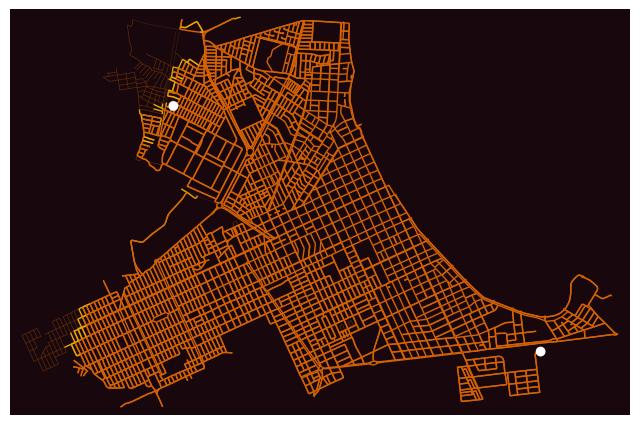

Distance: 8.118581375042702
Avg. speed: 42.82608695652174
Total time: 11.374256139653733


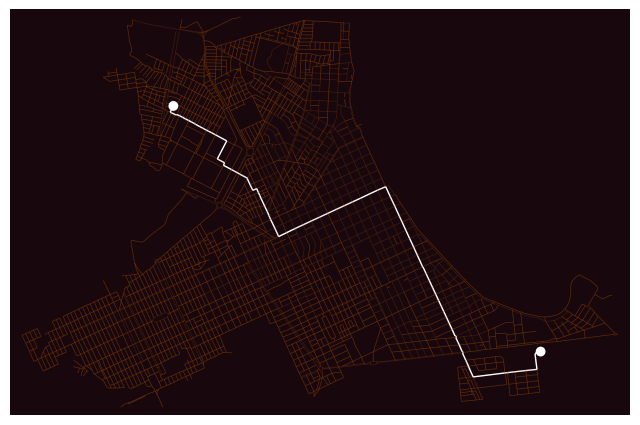

In [50]:
#start = random.choice(list(graph.nodes))
#end = random.choice(list(graph.nodes))
#start_point, end_point = (-42.760055, -65.064247), (-42.786794, -65.001571)
#start = ox.nearest_nodes(graph, X=start_point[0], Y=start_point[1])
#end = ox.nearest_nodes(graph, X=end_point[0], Y=end_point[1])
print("Start:", start)
print("End:", end)
dijkstra(start, end, plot=True)
reconstruct_path(start, end, plot=True)